
Processing 40 Hz

Processing 80 Hz

Processing 120 Hz

Processing 160 Hz

Processing 200 Hz

Processing 240 Hz

Processing 280 Hz

Processing 320 Hz

Processing 360 Hz

Processing 400 Hz


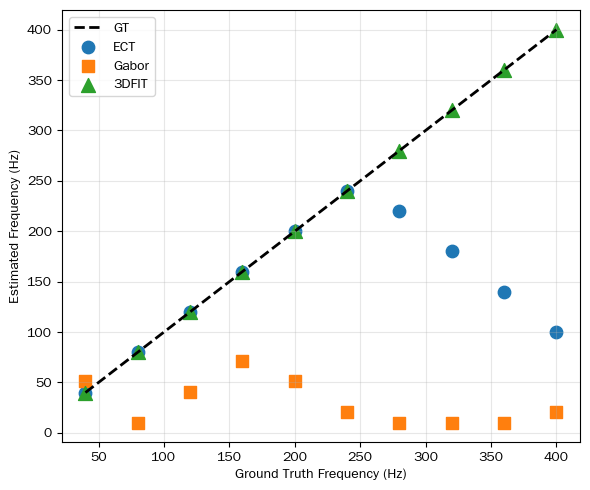


Amplitude estimation
Freq | ECT | Gabor | 3DFIT
   40 |   7.57 |   0.18 |   8.69
   80 |   5.51 |   0.23 |   8.70
  120 |   4.99 |   0.26 |   8.68
  160 |   3.85 |   0.19 |   8.70
  200 |   2.88 |   0.24 |   8.70
  240 |   2.34 |   0.23 |   8.69
  280 |   2.00 |   0.23 |   8.69
  320 |   1.88 |   0.27 |   8.70
  360 |   1.71 |   0.21 |   8.69
  400 |   1.35 |   0.29 |   8.70


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from scipy.signal import hilbert
import cv2


# =========================================================
# 1 配置参数
# =========================================================

class VibrationConfig:

    freq = 200.0
    amplitude = 10.0
    phase = 0.0

    rod_length = 400
    rod_width = 10
    rod_x_start = 200
    rod_y_center = 400

    t_total = 0.1
    t_resolution = 2e-6

    event_density = 2000

    # noise
    noise_level = 0.05
    background_ratio = 0.15
    temporal_jitter = 5e-6


# =========================================================
# 2 振动模型
# =========================================================

def y_vibration(t, cfg):

    return cfg.rod_y_center + cfg.amplitude * np.sin(
        2 * np.pi * cfg.freq * t + cfg.phase
    )


# =========================================================
# 3 生成事件
# =========================================================

def generate_rod_events(cfg):

    t_list = np.arange(
        0,
        cfg.t_total,
        cfg.t_resolution
    )

    x_coords = np.arange(
        cfg.rod_x_start,
        cfg.rod_x_start + cfg.rod_length
    )

    y_base = np.arange(
        cfg.rod_y_center - cfg.rod_width // 2,
        cfg.rod_y_center + cfg.rod_width // 2
    )

    X, Yb = np.meshgrid(x_coords, y_base)

    num_pixels = X.size

    x_e, y_e, t_e, p_e = [], [], [], []

    for t in t_list:

        y_cur = y_vibration(t, cfg)

        Y = Yb + (y_cur - cfg.rod_y_center)

        # spatial jitter
        Y += np.random.normal(
            0,
            cfg.noise_level * cfg.amplitude,
            Y.shape
        )

        n = int(
            cfg.event_density *
            cfg.t_resolution *
            num_pixels
        )

        if n <= 0:
            continue

        idx = np.random.choice(
            num_pixels,
            n,
            replace=True
        )

        x_e.append(X.flatten()[idx])
        y_e.append(Y.flatten()[idx])
        t_e.append(np.full(n, t))
        p_e.append(np.random.choice([-1, 1], n))

    x = np.concatenate(x_e)
    y = np.concatenate(y_e)
    t = np.concatenate(t_e)
    p = np.concatenate(p_e)

    # temporal jitter
    t += np.random.normal(
        0,
        cfg.temporal_jitter,
        len(t)
    )

    # background noise
    n_bg = int(len(t) * cfg.background_ratio)

    x_bg = np.random.uniform(
        x.min(),
        x.max(),
        n_bg
    )

    y_bg = np.random.uniform(
        y.min(),
        y.max(),
        n_bg
    )

    t_bg = np.random.uniform(
        t.min(),
        t.max(),
        n_bg
    )

    p_bg = np.random.choice([-1, 1], n_bg)

    x = np.concatenate([x, x_bg])
    y = np.concatenate([y, y_bg])
    t = np.concatenate([t, t_bg])
    p = np.concatenate([p, p_bg])

    return dict(
        x=x,
        y=y,
        t=t,
        p=p,
        xmin=int(np.floor(x.min())),
        xmax=int(np.ceil(x.max())),
        ymin=int(np.floor(y.min())),
        ymax=int(np.ceil(y.max()))
    )


# =========================================================
# 4 事件转帧
# =========================================================

def events_to_frames(events,
                     frame_dt=0.002):

    xmin, xmax = events['xmin'], events['xmax']
    ymin, ymax = events['ymin'], events['ymax']

    W = xmax - xmin + 1
    H = ymax - ymin + 1

    t0, t1 = events['t'].min(), events['t'].max()

    frames = []
    times = []

    n_frames = int((t1 - t0) / frame_dt)

    for k in range(n_frames):

        ta = t0 + k * frame_dt
        tb = ta + frame_dt

        mask = (
            (events['t'] >= ta) &
            (events['t'] < tb)
        )

        if np.sum(mask) < 50:
            continue

        frame = np.zeros((H, W), np.float32)

        xs = np.round(
            events['x'][mask]
        ).astype(int) - xmin

        ys = np.round(
            events['y'][mask]
        ).astype(int) - ymin

        ps = events['p'][mask]

        valid = (
            (xs >= 0) & (xs < W) &
            (ys >= 0) & (ys < H)
        )

        for x, y, p in zip(
            xs[valid],
            ys[valid],
            ps[valid]
        ):
            frame[y, x] += p

        frame = cv2.GaussianBlur(
            frame,
            (5,5),
            0
        )

        frames.append(frame)

        times.append((ta + tb)/2)

    return np.array(frames), np.array(times)


# =========================================================
# 5 ECT 方法
# =========================================================

def method_ect(events,
               dt=0.002):

    t0 = events['t'].min()
    t1 = events['t'].max()

    centers = []
    times = []

    n_bins = int((t1 - t0) / dt)

    for i in range(n_bins):

        ta = t0 + i * dt
        tb = ta + dt

        mask = (
            (events['t'] >= ta) &
            (events['t'] < tb)
        )

        if np.sum(mask) < 50:
            continue

        yc = np.mean(events['y'][mask])

        centers.append(yc)
        times.append((ta + tb)/2)

    centers = np.array(centers)
    times = np.array(times)

    centers -= centers.mean()

    centers = gaussian_filter(
        centers,
        sigma=1.0
    )

    fft = np.fft.rfft(centers)

    freqs = np.fft.rfftfreq(
        len(centers),
        d=times[1] - times[0]
    )

    f_est = freqs[np.argmax(np.abs(fft))]

    A_est = np.ptp(centers) / 2

    return f_est, A_est


# =========================================================
# 6 Complex Gabor
# =========================================================

def complex_gabor(frame,
                  ksize=31,
                  sigma=4.0,
                  theta=np.pi/2,
                  lambd=12.0):

    real_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma=0.5,
        psi=0
    )

    imag_kernel = cv2.getGaborKernel(
        (ksize, ksize),
        sigma,
        theta,
        lambd,
        gamma=0.5,
        psi=np.pi/2
    )

    real_resp = cv2.filter2D(
        frame,
        cv2.CV_32F,
        real_kernel
    )

    imag_resp = cv2.filter2D(
        frame,
        cv2.CV_32F,
        imag_kernel
    )

    return real_resp + 1j * imag_resp


# =========================================================
# 7 Gabor Phase 方法
# =========================================================

def method_gabor(frames,
                 times):

    complex_stack = []

    for f in frames:

        resp = complex_gabor(
            f,
            theta=np.pi/2
        )

        complex_stack.append(resp)

    complex_stack = np.array(complex_stack)

    phase = np.angle(complex_stack)

    amplitude = np.abs(complex_stack)

    phase_unwrap = np.unwrap(
        phase,
        axis=0
    )

    dphi = np.diff(
        phase_unwrap,
        axis=0
    )

    signal = np.sum(
        dphi * amplitude[:-1],
        axis=(1,2)
    ) / (
        np.sum(amplitude[:-1], axis=(1,2)) + 1e-6
    )

    signal -= np.mean(signal)

    signal = gaussian_filter(
        signal,
        sigma=1.0
    )

    dt = times[1] - times[0]

    fft_vals = np.fft.rfft(signal)

    freqs = np.fft.rfftfreq(
        len(signal),
        d=dt
    )

    spectrum = np.abs(fft_vals)

    f_est = freqs[np.argmax(spectrum)]

    A_est = np.ptp(signal) / 2

    return f_est, A_est


# =========================================================
# 8 3DFIT
# =========================================================

def group_model(data,
                A,
                f,
                phi,
                k,
                b):

    x, t = data

    return (
        A *
        np.sin(
            2 * np.pi * f * t + phi
        )
        + k * x + b
    )


def method_3dfit(events, cfg):

    x = events['x']
    y = events['y']
    t = events['t']

    bins = np.linspace(
        x.min(),
        x.max(),
        6
    )

    fs = []
    As = []

    for i in range(len(bins)-1):

        mask = (
            (x >= bins[i]) &
            (x < bins[i+1])
        )

        if np.sum(mask) < 200:
            continue

        try:

            popt, _ = curve_fit(
                group_model,
                (x[mask], t[mask]),
                y[mask],
                p0=[
                    cfg.amplitude,
                    cfg.freq,
                    0,
                    0,
                    y[mask].mean()
                ],
                maxfev=20000
            )

            fs.append(popt[1])

            As.append(abs(popt[0]))

        except:
            pass

    return np.mean(fs), np.mean(As)


# =========================================================
# 9 Frequency Sweep
# =========================================================

def frequency_comparison():

    freqs = np.arange(40, 401, 40)

    f_ect = []
    f_gabor = []
    f_3dfit = []

    A_ect = []
    A_gabor = []
    A_3dfit = []

    for f in freqs:

        print(f"\nProcessing {f} Hz")

        cfg = VibrationConfig()

        cfg.freq = f

        events = generate_rod_events(cfg)

        frames, times = events_to_frames(events)

        fe, Ae = method_ect(events)

        fg, Ag = method_gabor(
            frames,
            times
        )

        f3, A3 = method_3dfit(
            events,
            cfg
        )

        f_ect.append(fe)
        f_gabor.append(fg)
        f_3dfit.append(f3)

        A_ect.append(Ae)
        A_gabor.append(Ag)
        A_3dfit.append(A3)

    return (
        freqs,
        f_ect,
        f_gabor,
        f_3dfit,
        A_ect,
        A_gabor,
        A_3dfit
    )


# =========================================================
# 10 Plot
# =========================================================

def plot_frequency():

    (
        freqs,
        f_ect,
        f_gabor,
        f_3dfit,
        A_ect,
        A_gabor,
        A_3dfit
    ) = frequency_comparison()

    # =====================================================
    # Frequency
    # =====================================================
    plt.figure(figsize=(6,5))

    plt.plot(
        freqs,
        freqs,
        'k--',
        linewidth=2,
        label="GT"
    )

    plt.scatter(
        freqs,
        f_ect,
        marker='o',
        s=80,
        label="ECT"
    )

    plt.scatter(
        freqs,
        f_gabor,
        marker='s',
        s=80,
        label="Gabor"
    )

    plt.scatter(
        freqs,
        f_3dfit,
        marker='^',
        s=100,
        label="3DFIT"
    )

    plt.xlabel(
        "Ground Truth Frequency (Hz)"
    )

    plt.ylabel(
        "Estimated Frequency (Hz)"
    )

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Amplitude
    # =====================================================
    print("\nAmplitude estimation")
    print("Freq | ECT | Gabor | 3DFIT")

    for i in range(len(freqs)):

        print(
            f"{freqs[i]:5.0f} | "
            f"{A_ect[i]:6.2f} | "
            f"{A_gabor[i]:6.2f} | "
            f"{A_3dfit[i]:6.2f}"
        )


# =========================================================
# main
# =========================================================

if __name__ == "__main__":

    plot_frequency()

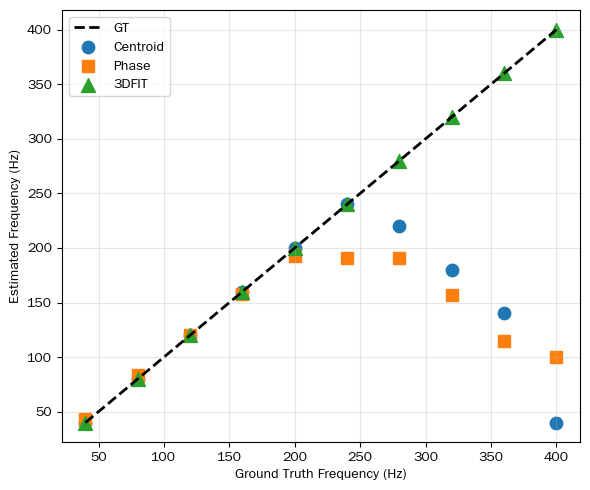


Amplitude estimation
Freq | Frame | Phase | 3DFIT
   40 |   7.72 |   5.74 |   8.69
   80 |   6.92 |   5.78 |   8.69
  120 |   6.44 |   4.99 |   8.70
  160 |   6.30 |   4.81 |   8.69
  200 |   5.61 |   4.47 |   8.69
  240 |   6.16 |   4.09 |   8.69
  280 |   4.61 |   3.30 |   8.69
  320 |   5.21 |   3.16 |   8.69
  360 |   4.66 |   2.34 |   8.70
  400 |   5.21 |   2.14 |   8.70


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from scipy.signal import hilbert


# =========================================================
# 1 配置参数
# =========================================================

class VibrationConfig:

    freq = 200.0
    amplitude = 10.0
    phase = 0.0

    rod_length = 400
    rod_width = 10
    rod_x_start = 200
    rod_y_center = 400

    t_total = 0.1
    t_resolution = 2e-6

    event_density = 2000

    # -------- 噪声参数 --------
    noise_level = 0.05          
    background_ratio = 0.15     
    temporal_jitter = 5e-6      


# =========================================================
# 2 振动模型
# =========================================================

def y_vibration(t, cfg):

    return cfg.rod_y_center + cfg.amplitude * np.sin(
        2 * np.pi * cfg.freq * t + cfg.phase
    )


# =========================================================
# 3 生成事件（增加噪声）
# =========================================================

def generate_rod_events(cfg):

    t_list = np.arange(0, cfg.t_total, cfg.t_resolution)

    x_coords = np.arange(cfg.rod_x_start,
                         cfg.rod_x_start + cfg.rod_length)

    y_base = np.arange(cfg.rod_y_center - cfg.rod_width // 2,
                       cfg.rod_y_center + cfg.rod_width // 2)

    X, Yb = np.meshgrid(x_coords, y_base)

    num_pixels = X.size

    x_e, y_e, t_e, p_e = [], [], [], []

    for t in t_list:

        y_cur = y_vibration(t, cfg)

        Y = Yb + (y_cur - cfg.rod_y_center)

        # -------- spatial jitter --------
        Y += np.random.normal(
            0,
            cfg.noise_level * cfg.amplitude,
            Y.shape
        )

        n = int(cfg.event_density * cfg.t_resolution * num_pixels)

        if n <= 0:
            continue

        idx = np.random.choice(num_pixels, n, replace=True)

        x_e.append(X.flatten()[idx])
        y_e.append(Y.flatten()[idx])
        t_e.append(np.full(n, t))
        p_e.append(np.random.choice([-1, 1], n))

    x = np.concatenate(x_e)
    y = np.concatenate(y_e)
    t = np.concatenate(t_e)
    p = np.concatenate(p_e)

    # -------- temporal jitter --------
    t += np.random.normal(0, cfg.temporal_jitter, len(t))

    # -------- background activity --------
    n_bg = int(len(t) * cfg.background_ratio)

    x_bg = np.random.uniform(x.min(), x.max(), n_bg)
    y_bg = np.random.uniform(y.min(), y.max(), n_bg)
    t_bg = np.random.uniform(t.min(), t.max(), n_bg)
    p_bg = np.random.choice([-1, 1], n_bg)

    x = np.concatenate([x, x_bg])
    y = np.concatenate([y, y_bg])
    t = np.concatenate([t, t_bg])
    p = np.concatenate([p, p_bg])

    return dict(
        x=x,
        y=y,
        t=t,
        p=p,
        xmin=int(np.floor(x.min())),
        xmax=int(np.ceil(x.max())),
        ymin=int(np.floor(y.min())),
        ymax=int(np.ceil(y.max()))
    )


# =========================================================
# 4 事件转帧
# =========================================================

def events_to_frames(events, frame_dt=0.002):

    xmin, xmax = events['xmin'], events['xmax']
    ymin, ymax = events['ymin'], events['ymax']

    W = xmax - xmin + 1
    H = ymax - ymin + 1

    t0, t1 = events['t'].min(), events['t'].max()

    frames = []
    times = []

    for k in range(int((t1 - t0) / frame_dt)):

        ta = t0 + k * frame_dt
        tb = ta + frame_dt

        mask = (events['t'] >= ta) & (events['t'] < tb)

        if np.sum(mask) < 50:
            continue

        frame = np.zeros((H, W), np.float32)

        xs = np.round(events['x'][mask]).astype(int) - xmin
        ys = np.round(events['y'][mask]).astype(int) - ymin
        ps = events['p'][mask]

        valid = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)

        for x, y, p in zip(xs[valid], ys[valid], ps[valid]):
            frame[y, x] += p

        frames.append(frame)
        times.append((ta + tb) / 2)

    return np.array(frames), np.array(times)


# =========================================================
# 5 Frame 方法
# =========================================================

def method_centerline(frames, times):

    centers = []

    for f in frames:

        y_prof = gaussian_filter(np.sum(f, axis=1), 1)

        y = np.arange(len(y_prof))

        if np.sum(np.abs(y_prof)) < 1e-6:
            continue

        centers.append(
            np.sum(y * np.abs(y_prof)) /
            np.sum(np.abs(y_prof))
        )

    centers = np.array(centers)
    times = times[:len(centers)]

    centers -= centers.mean()

    fft = np.fft.rfft(centers)
    freqs = np.fft.rfftfreq(len(centers), times[1] - times[0])

    f_est = freqs[np.argmax(np.abs(fft))]
    A_est = np.ptp(centers) / 2

    return f_est, A_est


# =========================================================
# 6 Phase 方法
# =========================================================

def method_phase_based(frames, times):

    centers = []

    for f in frames:

        y_prof = gaussian_filter(np.sum(f, axis=1), 1)

        y = np.arange(len(y_prof))

        if np.sum(np.abs(y_prof)) < 1e-6:
            continue

        centers.append(
            np.sum(y*np.abs(y_prof)) /
            np.sum(np.abs(y_prof))
        )

    centers = np.array(centers)
    times = times[:len(centers)]

    centers -= centers.mean()

    analytic = hilbert(centers)

    phase = np.unwrap(np.angle(analytic))

    envelope = np.abs(analytic)

    dt = times[1] - times[0]

    inst_freq = np.diff(phase) / (2*np.pi*dt)

    f_est = np.median(inst_freq)

    A_est = np.median(envelope)

    return f_est, A_est


# =========================================================
# 7 3DFIT
# =========================================================

def group_model(data, A, f, phi, k, b):

    x, t = data

    return A * np.sin(2 * np.pi * f * t + phi) + k * x + b


def method_3dfit(events, cfg):

    x = events['x']
    y = events['y']
    t = events['t']

    bins = np.linspace(x.min(), x.max(), 6)

    fs = []
    As = []

    for i in range(len(bins) - 1):

        mask = (x >= bins[i]) & (x < bins[i + 1])

        if np.sum(mask) < 200:
            continue

        try:

            popt, _ = curve_fit(
                group_model,
                (x[mask], t[mask]),
                y[mask],
                p0=[cfg.amplitude, cfg.freq, 0, 0, y[mask].mean()],
                maxfev=20000
            )

            fs.append(popt[1])
            As.append(abs(popt[0]))

        except:
            pass

    return np.mean(fs), np.mean(As)


# =========================================================
# 8 frequency sweep
# =========================================================

def frequency_comparison():

    freqs = np.arange(40, 401, 40)

    f_frame = []
    f_phase = []
    f_3dfit = []

    A_frame = []
    A_phase = []
    A_3dfit = []

    for f in freqs:

        cfg = VibrationConfig()
        cfg.freq = f

        events = generate_rod_events(cfg)

        frames, times = events_to_frames(events)

        ff, Af = method_centerline(frames, times)
        fp, Ap = method_phase_based(frames, times)
        f3, A3 = method_3dfit(events, cfg)

        f_frame.append(ff)
        f_phase.append(fp)
        f_3dfit.append(f3)

        A_frame.append(Af)
        A_phase.append(Ap)
        A_3dfit.append(A3)

    return freqs, f_frame, f_phase, f_3dfit, A_frame, A_phase, A_3dfit


# =========================================================
# 9 绘图
# =========================================================

def plot_frequency():

    freqs, f_frame, f_phase, f_3dfit, A_frame, A_phase, A_3dfit = frequency_comparison()

    plt.figure(figsize=(6,5))

    plt.plot(freqs, freqs, 'k--', linewidth=2, label="GT")

    plt.scatter(freqs, f_frame,
                marker='o', s=80, label="Centroid")

    plt.scatter(freqs, f_phase,
                marker='s', s=80, label="Phase")

    plt.scatter(freqs, f_3dfit,
                marker='^', s=100, label="3DFIT")

    plt.xlabel("Ground Truth Frequency (Hz)")
    plt.ylabel("Estimated Frequency (Hz)")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()


    
    print("\nAmplitude estimation")
    print("Freq | Frame | Phase | 3DFIT")

    for i in range(len(freqs)):

        print(
            f"{freqs[i]:5.0f} | "
            f"{A_frame[i]:6.2f} | "
            f"{A_phase[i]:6.2f} | "
            f"{A_3dfit[i]:6.2f}"
        )


# =========================================================
# main
# =========================================================

if __name__ == "__main__":

    plot_frequency()